In [45]:
#아두이노에서 측정되는 값을 시리얼 통신을 이용하여 파이썬으로 받아오기.

import serial
import time

serial_port = '/dev/cu.usbserial-11310'   #현재 사용하고 있는 포트 이름
ser = serial.Serial(serial_port, 115200)     #포트와 해당 보드레이트
value = []

check = input()
start_time = time.time()

while(1):
  
  if ser.readable():
    tem = ser.readline()
    val = tem.decode()
    l = list(val.split(','))
    l[-1] = l[-1].rstrip()
    l.append(float(time.time() - start_time))
    print(l)
    value.append(l)

['2.63', '-0.41', 0.0002422332763671875]
['2.84', '-0.36', 0.0005991458892822266]
['2.57', '0.69', 0.0006721019744873047]
['2.62', '0.20', 0.0007369518280029297]
['2.23', '-0.05', 0.0008060932159423828]
['2.09', '0.07', 0.0008702278137207031]
['2.23', '-0.36', 0.0009388923645019531]
['2.47', '0.36', 0.0010030269622802734]
['2.40', '0.41', 0.0010752677917480469]
['2.36', '0.32', 0.0011391639709472656]
['2.37', '0.23', 0.001203298568725586]
['0.13', '1.36', 0.0012731552124023438]
['0.24', '6.44', 0.001341104507446289]
['10.34', '-7.59', 0.001415252685546875]
['3.21', '2.68', 0.0014820098876953125]
['2.12', '1.23', 0.001544952392578125]
['1.47', '0.36', 0.0016088485717773438]
['9.41', '-5.28', 0.0016779899597167969]
['4.63', '-2.33', 0.0017480850219726562]
['-5.71', '2.58', 0.0018160343170166016]
['-13.73', '-1.56', 0.0018990039825439453]
['-17.18', '3.47', 0.0019750595092773438]
['-50.03', '9.70', 0.002048969268798828]
['-36.61', '7.24', 0.002123117446899414]
['-37.24', '4.63', 0.0021970

KeyboardInterrupt: 

In [46]:
#아두이노에서 받아온 값을 데이터프레임으로 저장.

import pandas as pd

df = pd.DataFrame(value, columns=["Roll", "Pitch", "Time"])
df = df.dropna()
df = df.astype(float)
df['Time'] = df['Time'].apply(lambda x: round(x, 4))

file_name = input()
df.to_csv("../data/" + file_name + ".csv", encoding='utf-8', index=False)

AxesSubplot(0.125,0.11;0.775x0.77)


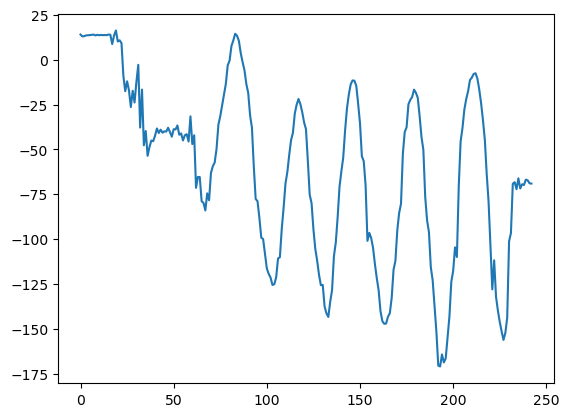

In [9]:
print(df["Roll"].plot())

In [ ]:
#getData로 가져온 df를 다른 이름으로 저장하기.
def setData(df):
    dict = {}
    dict.update({'Roll' : df['Roll'].values.tolist()})
    dict.update({'Pitch' : df['Pitch'].values.tolist()})
    dict.update({'Yaw' : df['Yaw'].values.tolist()})
    dict.update({'Time' : df['Time'].values.tolist()})

    name = input()
    new_dir = db.reference(name)
    new_dir.update(dict)
    